# WGAN paper figure 3 reproduction

This notebook reproduces the example comparing gradients of:
- Simple GANs
- Wasserstein GANs

For a distribution of 2 normals away from the origin
- mean = +5,-5
- std of normal = 1

In [1]:
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

## 1. Setup: two well-separated Gaussians

- **Real** $P_r = \mathcal{N}(-5, 1)$
- **Fake** $P_g = \mathcal{N}(+5, 1)$

Placed 10 standard deviations apart → effectively disjoint support.

In [2]:
real_mean, real_std = -5.0, 1.0
fake_mean, fake_std =  5.0, 1.0

x_axis = np.linspace(-8, 8, 1000)

## 2. Minimal numpy MLP helpers

Architecture shared by both models: `Linear(1→64) → ReLU → Linear(64→64) → ReLU → Linear(64→1)`

The only difference:
- **GAN**: sigmoid on output + BCE loss
- **WGAN**: linear output + Wasserstein loss + weight clipping after each step

In [3]:
def init_mlp(layer_sizes, weight_clip_val=None):
    """Xavier init, optionally clipped (to start inside Lipschitz constraint)."""
    params = [(np.random.randn(fan_in, fan_out) * np.sqrt(2 / fan_in), np.zeros(fan_out))
              for fan_in, fan_out in zip(layer_sizes, layer_sizes[1:])]
    return weight_clip(params, weight_clip_val) if weight_clip_val else params


def forward(params, x, sigmoid_output=False):
    current_activation, layer_cache = x, []
    for layer_idx, (weight, bias) in enumerate(params):
        pre_activation = current_activation @ weight + bias
        is_final_layer = (layer_idx == len(params) - 1)
        if is_final_layer and sigmoid_output:
            post_activation = 1.0 / (1.0 + np.exp(-np.clip(pre_activation, -30, 30)))
        elif not is_final_layer:
            post_activation = np.maximum(0, pre_activation)   # ReLU
        else:
            post_activation = pre_activation                   # linear output for WGAN critic
        layer_cache.append((current_activation, pre_activation, post_activation))
        current_activation = post_activation
    return current_activation, layer_cache


def backward(params, layer_cache, upstream_grad, sigmoid_output=False):
    param_grads, grad = [], upstream_grad
    for layer_idx in reversed(range(len(params))):
        prev_activation, pre_activation, post_activation = layer_cache[layer_idx]
        weight, _ = params[layer_idx]
        is_final_layer = (layer_idx == len(params) - 1)
        if is_final_layer and sigmoid_output:
            grad = grad * post_activation * (1 - post_activation)           # sigmoid grad
        elif not is_final_layer:
            grad = grad * (pre_activation > 0).astype(float)                # ReLU grad
        param_grads.insert(0, (prev_activation.T @ grad / prev_activation.shape[0], grad.mean(0)))
        grad = grad @ weight.T
    return param_grads


def adam_update(params, param_grads, first_moment, second_moment, step, lr,
                beta1=0.9, beta2=0.999, epsilon=1e-8):
    updated_params, updated_first_moment, updated_second_moment = [], [], []
    for (weight, bias), (weight_grad, bias_grad), \
        (weight_m1, bias_m1), (weight_m2, bias_m2) in zip(params, param_grads, first_moment, second_moment):

        weight_m1 = beta1 * weight_m1 + (1 - beta1) * weight_grad
        bias_m1   = beta1 * bias_m1   + (1 - beta1) * bias_grad
        weight_m2 = beta2 * weight_m2 + (1 - beta2) * weight_grad ** 2
        bias_m2   = beta2 * bias_m2   + (1 - beta2) * bias_grad ** 2

        weight = weight - lr * (weight_m1 / (1 - beta1 ** step)) / (np.sqrt(weight_m2 / (1 - beta2 ** step)) + epsilon)
        bias   = bias   - lr * (bias_m1   / (1 - beta1 ** step)) / (np.sqrt(bias_m2   / (1 - beta2 ** step)) + epsilon)

        updated_params.append((weight, bias))
        updated_first_moment.append((weight_m1, bias_m1))
        updated_second_moment.append((weight_m2, bias_m2))
    return updated_params, updated_first_moment, updated_second_moment


def init_adam_moments(params):
    first_moment  = [(np.zeros_like(weight), np.zeros_like(bias)) for weight, bias in params]
    second_moment = [(np.zeros_like(weight), np.zeros_like(bias)) for weight, bias in params]
    return first_moment, second_moment


def weight_clip(params, clip_threshold):
    """Weight clipping — the key operation in WGAN Algorithm 1."""
    return [(np.clip(weight, -clip_threshold, clip_threshold),
             np.clip(bias,   -clip_threshold, clip_threshold))
            for weight, bias in params]

## 3. Train the GAN Discriminator to optimality

$$\max_D \; \mathbb{E}_{x \sim P_r}[\log D(x)] + \mathbb{E}_{x \sim P_g}[\log(1 - D(x))]$$

With disjoint support the discriminator quickly learns $D^*(x) \approx 1$ on $P_r$ and $D^*(x) \approx 0$ on $P_g$, producing **zero gradient** for the generator.

In [4]:
layer_sizes = [1, 64, 64, 1]
batch_size = 256

disc_params = init_mlp(layer_sizes)
disc_first_moment, disc_second_moment = init_adam_moments(disc_params)

for step in range(1, 1501):
    real_samples = np.random.normal(real_mean, real_std, (batch_size, 1))
    fake_samples = np.random.normal(fake_mean, fake_std, (batch_size, 1))

    disc_on_real, cache_real = forward(disc_params, real_samples, sigmoid_output=True)
    disc_on_fake, cache_fake = forward(disc_params, fake_samples, sigmoid_output=True)

    # Gradient of -[log D(real) + log(1-D(fake))]
    upstream_grad_real = -(1.0 / (disc_on_real + 1e-8))
    upstream_grad_fake =  (1.0 / (1 - disc_on_fake + 1e-8))

    grads_from_real = backward(disc_params, cache_real, upstream_grad_real, sigmoid_output=True)
    grads_from_fake = backward(disc_params, cache_fake, upstream_grad_fake, sigmoid_output=True)
    combined_grads  = [(0.5 * (dW_r + dW_f), 0.5 * (db_r + db_f))
                       for (dW_r, db_r), (dW_f, db_f) in zip(grads_from_real, grads_from_fake)]

    disc_params, disc_first_moment, disc_second_moment = adam_update(
        disc_params, combined_grads, disc_first_moment, disc_second_moment, step, lr=1e-3)

print('GAN discriminator trained (1500 steps)')

GAN discriminator trained (1500 steps)


## 4. Train the WGAN Critic

$$\max_w \; \mathbb{E}_{x \sim P_r}[f_w(x)] - \mathbb{E}_{x \sim P_g}[f_w(x)]$$

Lipschitz constraint enforced by **weight clipping** to $[-c, c]$ after every update, with $c = 0.01$ (paper default).

> *"The fact that we constrain the weights limits the possible growth of the function to be at most linear in different parts of the space, **forcing the optimal critic to have this behaviour**."*

In [ ]:
WEIGHT_CLIP_THRESHOLD = 0.05   # paper default

critic_params = init_mlp(layer_sizes, weight_clip_val=WEIGHT_CLIP_THRESHOLD)   # start inside constraint set
critic_first_moment, critic_second_moment = init_adam_moments(critic_params)

for step in range(1, 3001):
    real_samples = np.random.normal(real_mean, real_std, (batch_size, 1))
    fake_samples = np.random.normal(fake_mean, fake_std, (batch_size, 1))

    critic_on_real, cache_real = forward(critic_params, real_samples)   # linear output
    critic_on_fake, cache_fake = forward(critic_params, fake_samples)

    # Gradient of (E[f(real)] - E[f(fake)])
    upstream_grad_real = np.ones_like(critic_on_real)
    upstream_grad_fake = -np.ones_like(critic_on_fake)

    combined_grads = [(0.5 * (dW_r + dW_f), 0.5 * (db_r + db_f))
                      for (dW_r, db_r), (dW_f, db_f) in zip(
                          backward(critic_params, cache_real, upstream_grad_real),
                          backward(critic_params, cache_fake, upstream_grad_fake))]

    critic_params, critic_first_moment, critic_second_moment = adam_update(
        critic_params, combined_grads, critic_first_moment, critic_second_moment, step, lr=5e-5)

    # ← Algorithm 1, line 7: clip weights
    critic_params = weight_clip(critic_params, WEIGHT_CLIP_THRESHOLD)

print('WGAN critic trained (3000 steps)')

WGAN critic trained (3000 steps)


## 5. Evaluate and plot

Critic   range: [-0.6120, 0.7310]
Discrim  range: [0.0000, 1.0000]


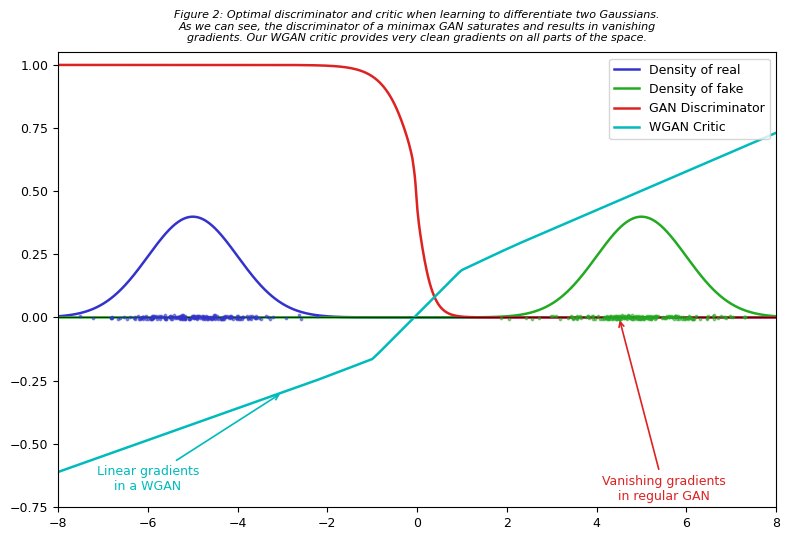

In [6]:
x_eval = x_axis.reshape(-1, 1)
disc_curve, _ = forward(disc_params, x_eval, sigmoid_output=True)
disc_curve = disc_curve.flatten()
critic_curve, _ = forward(critic_params, x_eval)
critic_curve = critic_curve.flatten()

print(f'Critic   range: [{critic_curve.min():.4f}, {critic_curve.max():.4f}]')
print(f'Discrim  range: [{disc_curve.min():.4f}, {disc_curve.max():.4f}]')

# Annotation targets (scalar values at specific x positions)
critic_annotation_y  = float(forward(critic_params, np.array([[-3.0]]))[0].item())
disc_annotation_y    = float(forward(disc_params,   np.array([[4.5]]), sigmoid_output=True)[0].item())
y_axis_bottom        = float(critic_curve.min())

# Scatter samples (jittered onto the x-axis for visibility)
real_scatter_x = np.random.normal(real_mean, real_std, 200)
fake_scatter_x = np.random.normal(fake_mean, fake_std, 200)
jitter = lambda: np.random.uniform(-0.008, 0.008, 200)

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.plot(x_axis, norm.pdf(x_axis, real_mean, real_std), color='#3333cc', lw=1.8, label='Density of real')
ax.plot(x_axis, norm.pdf(x_axis, fake_mean, fake_std), color='#22aa22', lw=1.8, label='Density of fake')
ax.plot(x_axis, disc_curve,   color='#dd2222', lw=1.8, label='GAN Discriminator')
ax.plot(x_axis, critic_curve, color='#00bbbb', lw=1.8, label='WGAN Critic')

ax.scatter(real_scatter_x, jitter(), color='#3333cc', s=3, alpha=0.5, zorder=5)
ax.scatter(fake_scatter_x, jitter(), color='#22aa22', s=3, alpha=0.5, zorder=5)

ax.annotate('Linear gradients\nin a WGAN',
            xy=(-3., critic_annotation_y), xytext=(-6., y_axis_bottom - 0.07),
            color='#00bbbb', fontsize=9, ha='center',
            arrowprops=dict(arrowstyle='->', color='#00bbbb', lw=1.2))

ax.annotate('Vanishing gradients\nin regular GAN',
            xy=(4.5, disc_annotation_y), xytext=(5.5, y_axis_bottom - 0.11),
            color='#dd2222', fontsize=9, ha='center',
            arrowprops=dict(arrowstyle='->', color='#dd2222', lw=1.2))

ax.set_xlim(-8, 8)
ax.set_ylim(y_axis_bottom - 0.14, 1.05)
ax.axhline(0, color='black', lw=0.5)
ax.legend(loc='upper right', fontsize=9)
ax.tick_params(labelsize=9)

ax.set_title(
    'Figure 2: Optimal discriminator and critic when learning to differentiate two Gaussians.\n'
    'As we can see, the discriminator of a minimax GAN saturates and results in vanishing\n'
    'gradients. Our WGAN critic provides very clean gradients on all parts of the space.',
    fontsize=8, style='italic', pad=8)

plt.tight_layout()
plt.show()